# Example Script

Baseline Ito (alpha=0) comparison.

Run this as a script or interactively with cell markers.
To run from this directory: python baseline_ito_comparison.py

Compares DTO, PINN, and BiLO on a shared synthetic field problem and plots
diagnostics.

### Cell 1: Setup


In [1]:
import numpy as np
import torch

from interface import Problem, solve, show_settings
import diagnostics


### Cell 2: Settings (shared + field)


In [7]:
# Note: many options are left at defaults (see show_settings() for the full list).

# show_settings()
# NOTE: when configs are merged with **{...}, later dicts override earlier keys.
# Optional knobs left at defaults here: use_ddi/d_init_base, w_data, log_every, use_rff_geom/use_rff_logd.
SHARED_CONFIG = {
    "max_iters": 10000,
    "lr_d": 1e-4,
    "wreg_smooth": 1e-5, # weak regularization
    "wreg_scale": 1e-5,
    "smoothness_type": "h1", # or 'tv'
    "d_init_scale": 0.25,  # relative Dinit amplitude for pretrain
    "d_init_freq": 2.0,
    "use_scheduler": True,
    "early_burnin": 2500,
    "early_patience": 500,
    "early_tol": 1e-4, # relative to total loss
    "n_res": 201
}

DTO_FIELD_CONFIG = {
    "field_loss": "rle",  # field-mode data loss
}

PINN_FIELD_CONFIG = {
    "pretrain_iters": 2000,
    "field_loss": "rle",  # field-mode data loss
    "lr_lower": 1e-4,
    "w_phys": 1.0,
    "w_jump": 1.0,
    "use_rff": True,
}

BILO_FIELD_CONFIG = {
    "pretrain_iters": 2000,
    "field_loss": "rle",  # field-mode data loss
    "lr_lower": 1e-4,
    "w_jump": 1.0,
    "w_resgrad": 1e-1,
    "use_rff": True,
    "early_tol": 1e-6, # BILO needs stricter early stop for some reason
}

### Cell 3: Create problem


In [ ]:
# Synthetic problem with explicit physics parameters
problem = Problem.synthetic(
    alpha=0.0,  # Ito convention
    mode="field",  # "field" uses dense u(x)
    d_profile="sinusoidal",  # D(x) profile family
    d_profile_params=(0.1, 0.04, 4.0),  # (mean, amplitude, frequency)
    mu=5.0,  # death rate
    source_location=0.5,  # point source location
    b_true=100.0,  # source strength
    n_obs=201,  # observation grid
    seed=42,  # RNG seed
)

print(
    f"[Synthetic] α: {problem.alpha} | μ: {problem.mu} | b₀: {problem.b_true} | "
    f"Grid: {len(problem.x_grid)} pts"
)
mean_d_true = float(np.mean(problem.d_true)) if problem.d_true is not None else None

[Problem] Field: ∫u 1.899e+01 | ⟨D⟩_true: 1.000e-01
[Synthetic] α: 0.0 | μ: 5.0 | b₀: 100.0 | Grid: 201 pts


### Cell 4: DTO



--- DTO ---
[Solve] Method: DTO | α: 0.0 | Mode: field
[DTO] Initialized ⟨D⟩_base: 6.831e-02
[DTO] Iter 00000 | Ltot: 1.018e-01
  Ldata(rle): 1.017e-01 | RegSmooth: 5.078e+00 (eff: 5.078e-05) | RegScale: 3.249e-02 (eff: 3.249e-07)
  b₀*: 93.20 | ∫u: 1.815e+01 | ⟨D⟩: 6.831e-02
[DTO] Iter 00200 | Ltot: 9.388e-02
  Ldata(rle): 9.382e-02 | RegSmooth: 5.383e+00 (eff: 5.383e-05) | RegScale: 3.030e-02 (eff: 3.030e-07)
  b₀*: 93.85 | ∫u: 1.828e+01 | ⟨D⟩: 6.799e-02
[DTO] Iter 00400 | Ltot: 8.650e-02
  Ldata(rle): 8.644e-02 | RegSmooth: 6.254e+00 (eff: 6.254e-05) | RegScale: 2.879e-02 (eff: 2.879e-07)
  b₀*: 94.43 | ∫u: 1.839e+01 | ⟨D⟩: 6.772e-02
[DTO] Iter 00600 | Ltot: 7.962e-02
  Ldata(rle): 7.955e-02 | RegSmooth: 7.321e+00 (eff: 7.321e-05) | RegScale: 2.791e-02 (eff: 2.791e-07)
  b₀*: 94.94 | ∫u: 1.849e+01 | ⟨D⟩: 6.751e-02
[DTO] Iter 00800 | Ltot: 7.322e-02
  Ldata(rle): 7.314e-02 | RegSmooth: 8.520e+00 (eff: 8.520e-05) | RegScale: 2.759e-02 (eff: 2.759e-07)
  b₀*: 95.40 | ∫u: 1.858e+01 | ⟨

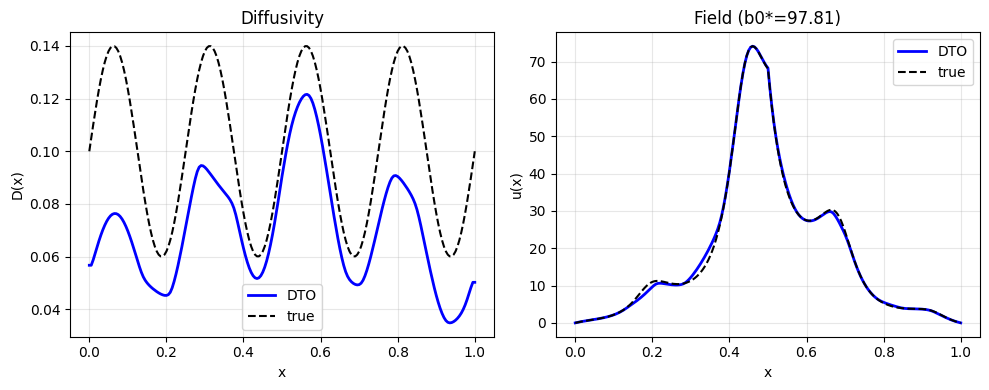

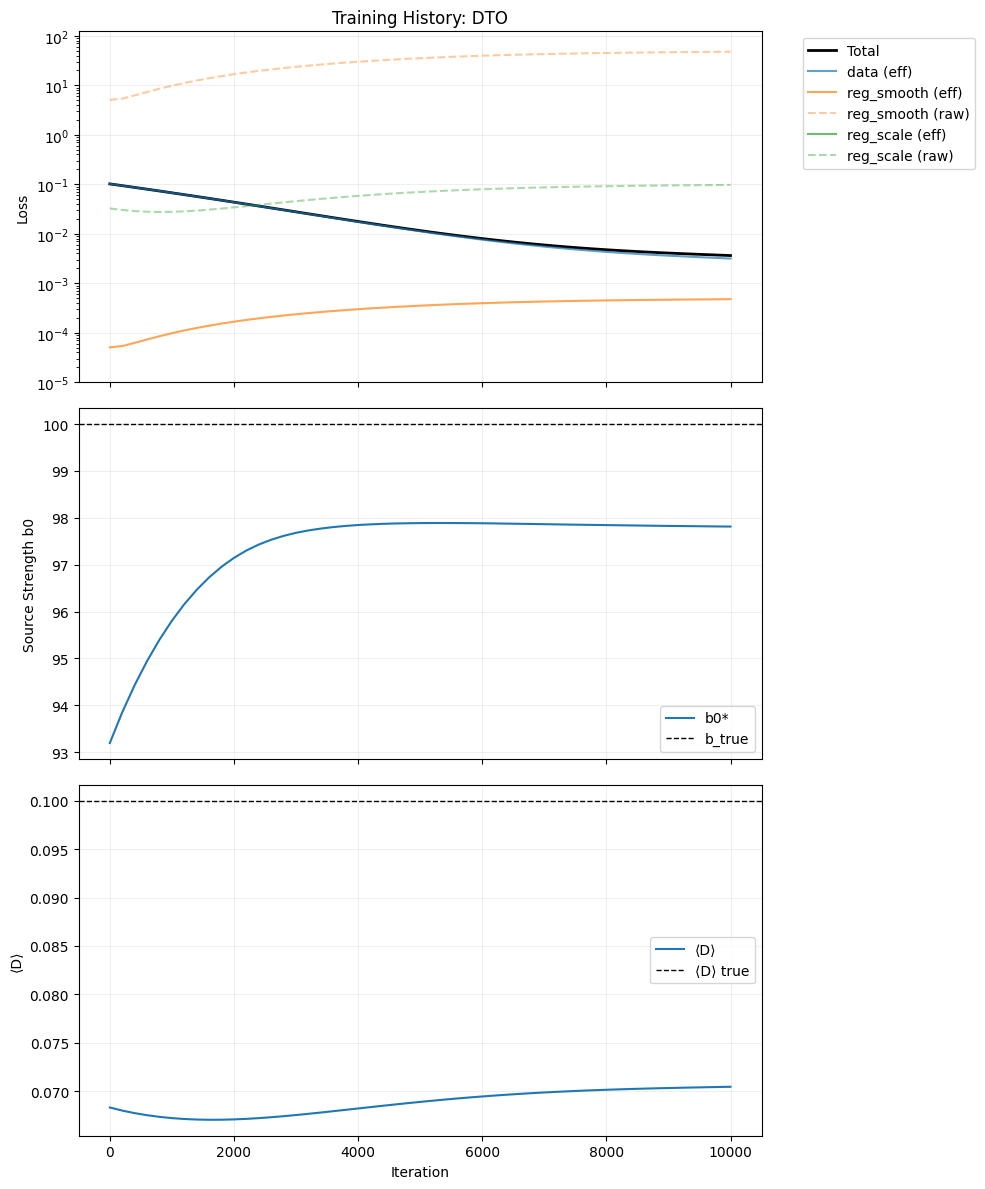

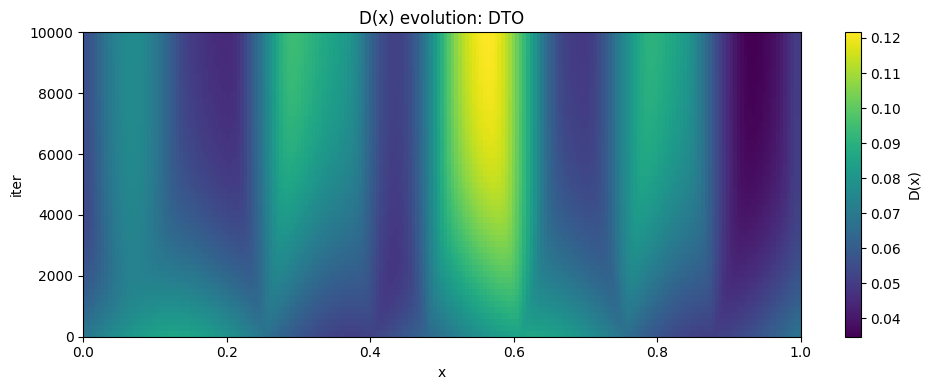

In [4]:
print("\n--- DTO ---")
# DTO (Discretize-Then-Optimize) options (field mode).
dto_solution = solve(
    problem,
    method="dto",  # discretize-then-optimize solver
    **{**SHARED_CONFIG, **DTO_FIELD_CONFIG},
)
dto_metrics = dto_solution.metrics(problem)
print(f"DTO: D(x) rel error = {dto_metrics['d_rel_error']:.2%}, b0* = {dto_solution.b0_star:.2f}")
dto_solution.plot(problem)
diagnostics.plot_training_history(
    "DTO",
    dto_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=dto_solution.weights,
)
diagnostics.plot_d_evolution(
    "DTO",
    dto_solution.history,
    dto_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 5: PINN



--- PINN ---
[Solve] Method: PINN | α: 0.0 | Mode: field
[PINN] Initialized ⟨D⟩_base: 6.831e-02
[PINN|pretrain] Iter 00000 | Ltot: 1.133e+01
  Lphys: 4.554e+00 | Lanchor: 6.773e+00
  Lres: 3.556e+00 | Ljump: 9.979e-01
  ⟨D⟩: 9.221e-01
[PINN|pretrain] Iter 00200 | Ltot: 4.083e-01
  Lphys: 3.897e-01 | Lanchor: 1.860e-02
  Lres: 9.848e-02 | Ljump: 2.912e-01
  ⟨D⟩: 7.534e-02
[PINN|pretrain] Iter 00400 | Ltot: 8.089e-02
  Lphys: 5.890e-02 | Lanchor: 2.199e-02
  Lres: 3.046e-02 | Ljump: 2.844e-02
  ⟨D⟩: 7.531e-02
[PINN|pretrain] Iter 00600 | Ltot: 1.245e-02
  Lphys: 8.626e-03 | Lanchor: 3.822e-03
  Lres: 7.185e-03 | Ljump: 1.440e-03
  ⟨D⟩: 7.009e-02
[PINN|pretrain] Iter 00800 | Ltot: 2.781e-03
  Lphys: 1.430e-03 | Lanchor: 1.351e-03
  Lres: 1.400e-03 | Ljump: 3.017e-05
  ⟨D⟩: 6.856e-02
[PINN|pretrain] Iter 01000 | Ltot: 1.122e-03
  Lphys: 4.482e-04 | Lanchor: 6.742e-04
  Lres: 4.469e-04 | Ljump: 1.328e-06
  ⟨D⟩: 6.837e-02
[PINN|pretrain] Iter 01200 | Ltot: 7.081e-04
  Lphys: 2.505e-04 | Lan

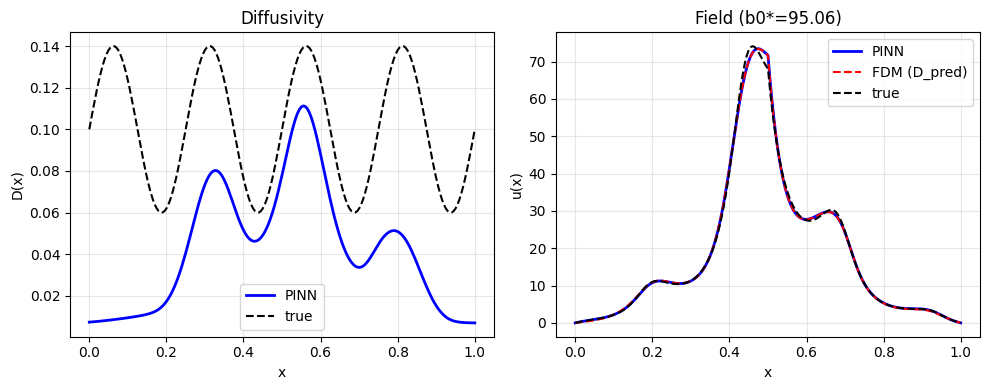

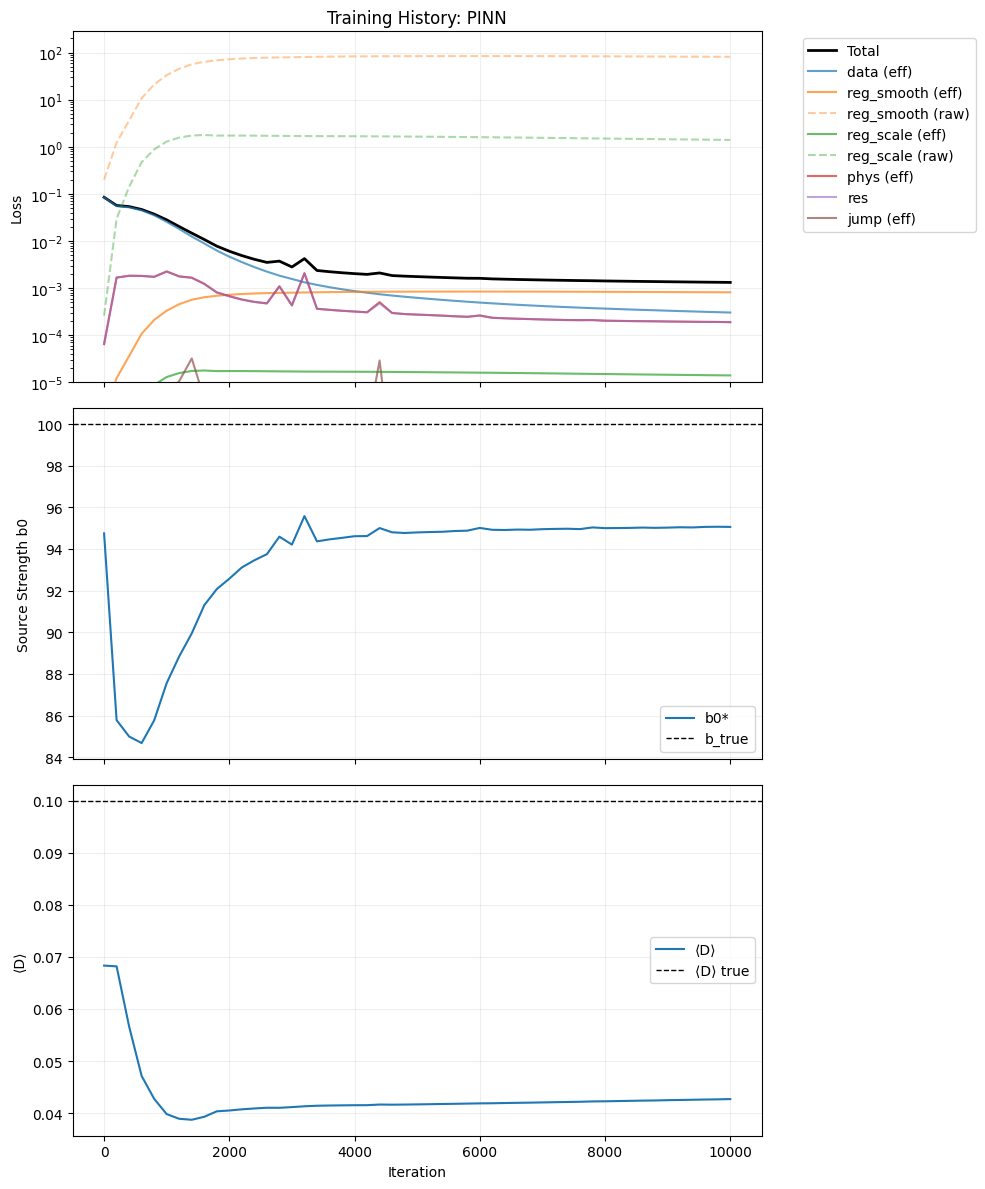

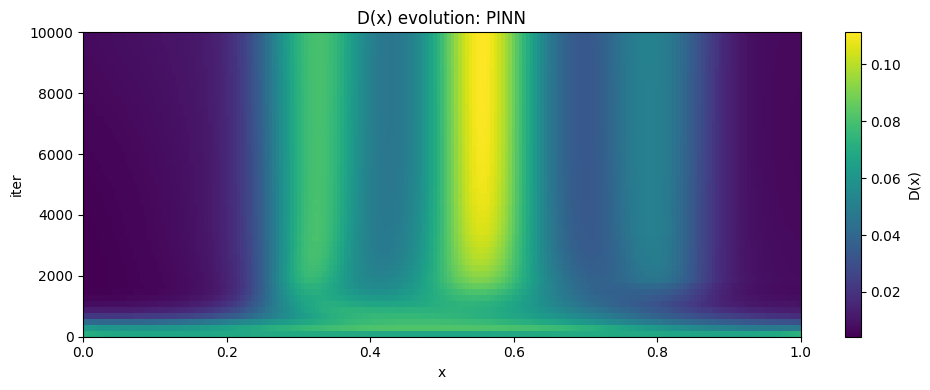

In [5]:
print("\n--- PINN ---")
# PINN (Physics-Informed Neural Network) options (field mode).
pinn_solution = solve(
    problem,
    method="pinn",  # physics-informed neural network
    **{**SHARED_CONFIG, **PINN_FIELD_CONFIG},
)
pinn_metrics = pinn_solution.metrics(problem)
print(f"PINN: D(x) rel error = {pinn_metrics['d_rel_error']:.2%}, b0* = {pinn_solution.b0_star:.2f}")
pinn_solution.plot(problem)
diagnostics.plot_training_history(
    "PINN",
    pinn_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=pinn_solution.weights,
)
diagnostics.plot_d_evolution(
    "PINN",
    pinn_solution.history,
    pinn_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 6: BiLO



--- BiLO ---
[Solve] Method: BILO | α: 0.0 | Mode: field
[BiLO] Initialized ⟨D⟩_base: 6.831e-02
[BiLO|pretrain] Iter 00000 | Ltot: 1.148e+01
  Lanchor: 6.868e+00 | Llower: 4.565e+00 | Lsup: 4.232e-02
  Lres: 3.378e+00 | Ljump: 1.002e+00 | Lrgrad: 1.849e+00 | Ljump_rgrad: 1.830e-04
  ⟨D⟩: 8.964e-01
[BiLO|pretrain] Iter 00200 | Ltot: 1.034e+00
  Lanchor: 2.695e-02 | Llower: 9.440e-01 | Lsup: 6.298e-02
  Lres: 3.832e-02 | Ljump: 9.046e-01 | Lrgrad: 6.447e-03 | Ljump_rgrad: 4.733e-03
  ⟨D⟩: 6.799e-02
[BiLO|pretrain] Iter 00400 | Ltot: 5.100e-01
  Lanchor: 1.684e-02 | Llower: 4.639e-01 | Lsup: 2.925e-02
  Lres: 5.002e-02 | Ljump: 3.157e-01 | Lrgrad: 7.122e-01 | Ljump_rgrad: 2.698e-01
  ⟨D⟩: 6.803e-02
[BiLO|pretrain] Iter 00600 | Ltot: 1.967e-01
  Lanchor: 1.045e-02 | Llower: 1.799e-01 | Lsup: 6.372e-03
  Lres: 3.728e-02 | Ljump: 6.690e-02 | Lrgrad: 2.182e-01 | Ljump_rgrad: 5.387e-01
  ⟨D⟩: 6.792e-02
[BiLO|pretrain] Iter 00800 | Ltot: 7.013e-02
  Lanchor: 5.727e-03 | Llower: 6.350e-02 | Lsu

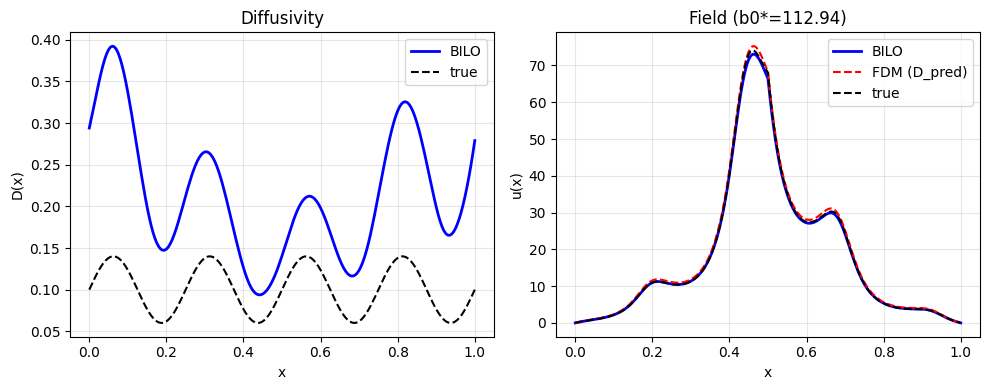

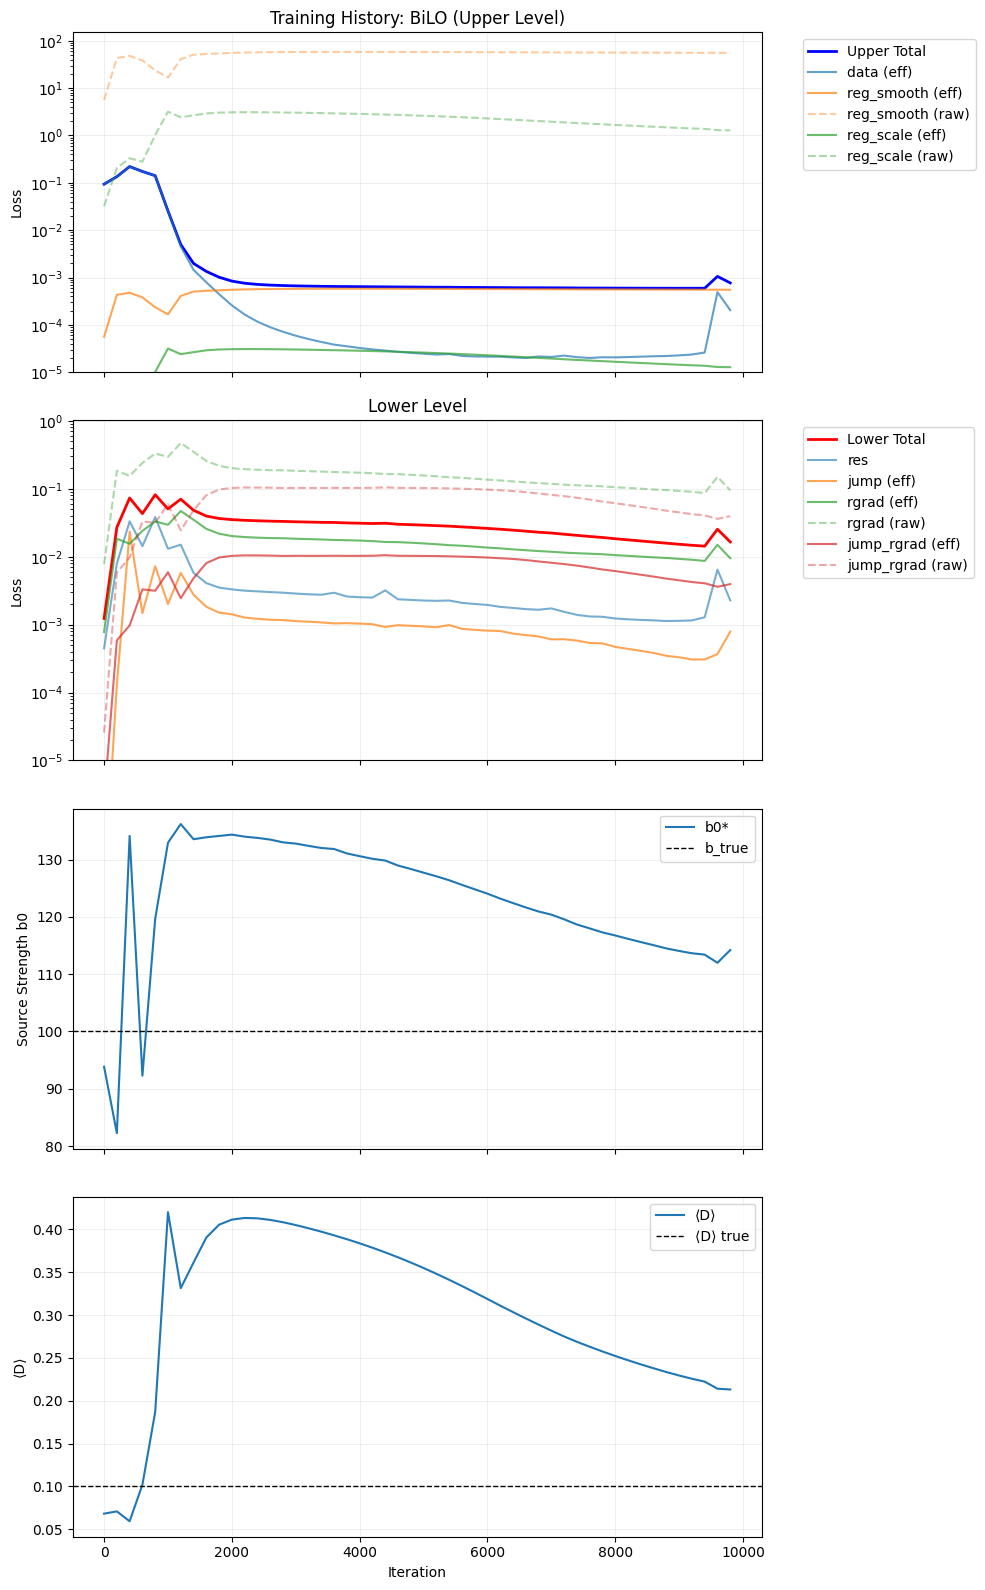

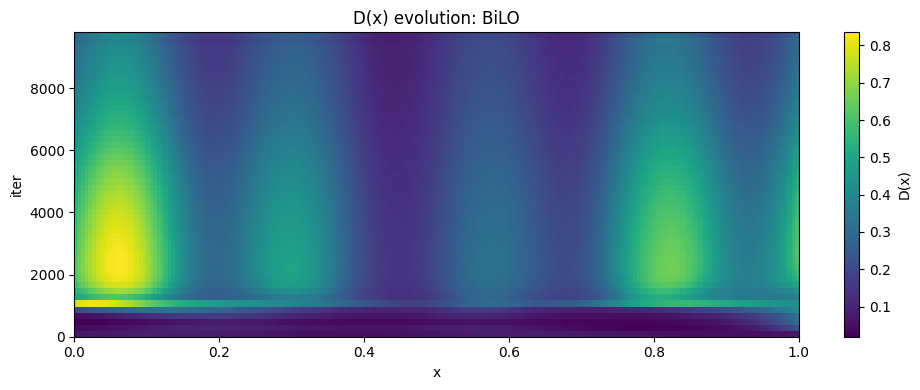

In [8]:
print("\n--- BiLO ---")
# BiLO (Bilevel Optimization) options (field mode).
bilo_solution = solve(
    problem,
    method="bilo",  # bilevel local operator
    **{**SHARED_CONFIG, **BILO_FIELD_CONFIG},
)
bilo_metrics = bilo_solution.metrics(problem)
print(f"BiLO: D(x) rel error = {bilo_metrics['d_rel_error']:.2%}, b0* = {bilo_solution.b0_star:.2f}")
bilo_solution.plot(problem)
diagnostics.plot_training_history(
    "BiLO",
    bilo_solution.history,
    problem.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=bilo_solution.weights,
)
diagnostics.plot_d_evolution(
    "BiLO",
    bilo_solution.history,
    bilo_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)


### Cell 7: Particle settings


In [9]:
DTO_PARTICLE_CONFIG = {
    "wreg_smooth": 1e-2, # stronger regularization for particles
}

PINN_PARTICLE_CONFIG = {
    "pretrain_iters": 1000,
    "wreg_smooth": 1e-2, # stronger regularization for particles
    "lr_lower": 1e-4,
    "w_phys": 10.0,
    "w_jump": 1e-1,
    "use_rff": True,
}

BILO_PARTICLE_CONFIG = {
    "pretrain_iters": 3000, # pretrain more so jump loss ->0 too
    "wreg_smooth": 1e-4, # stronger? regularization for particles
    "wreg_scale": 1e-4, # stronger? regularization for particles
    "lr_lower": 1e-4,
    "w_jump": 1.0,
    "w_resgrad": 0.01, # not sure what to set this
    "use_rff": True,
    "early_tol": 1e-6, # bilo stops early for some odd reason i cant figure out 
}


# Generate particle data

In [13]:
print("\n--- Particle Mode Setup ---")
problem_ppp = Problem.synthetic(
    alpha=0.0,  # Ito convention
    mode="particles",  # particle PPP observations
    d_profile="sinusoidal",  # D(x) profile family
    d_profile_params=(0.1, 0.04, 4.0),  # (mean, amplitude, frequency)
    mu=5.0,  # death rate
    source_location=0.5,  # point source location
    b_true=100.0,  # source strength
    m_obs=1000,  # PPP snapshots
    use_pde_sampling=True,  # sample PPP from PDE field instead of SDE
    seed=42,  # RNG seed
)


mean_d_true_ppp = float(np.mean(problem_ppp.d_true)) if problem_ppp.d_true is not None else None


--- Particle Mode Setup ---
[Problem] Particles: n_obs 19095 | m_obs 1000 | ⟨n⟩/obs 19.09 | ⟨D⟩_true: 1.000e-01


### Cell 7: Particle observations (DTO)



--- DTO (particles) ---
[Solve] Method: DTO | α: 0.0 | Mode: particles
[DTO] Initialized ⟨D⟩_base: 6.873e-02
[DTO] Iter 00000 | Ltot: -4.603e+01
  Ldata(ppp): -4.608e+01 | RegSmooth: 5.078e+00 (eff: 5.078e-02) | RegScale: 3.249e-02 (eff: 3.249e-07)
  b₀*: 98.08 | ∫u: 1.909e+01 | ⟨D⟩: 6.873e-02
[DTO] Iter 00200 | Ltot: -4.611e+01
  Ldata(ppp): -4.616e+01 | RegSmooth: 4.655e+00 (eff: 4.655e-02) | RegScale: 2.980e-02 (eff: 2.980e-07)
  b₀*: 98.09 | ∫u: 1.909e+01 | ⟨D⟩: 6.860e-02
[DTO] Iter 00400 | Ltot: -4.618e+01
  Ldata(ppp): -4.623e+01 | RegSmooth: 4.501e+00 (eff: 4.501e-02) | RegScale: 2.772e-02 (eff: 2.772e-07)
  b₀*: 98.10 | ∫u: 1.909e+01 | ⟨D⟩: 6.853e-02
[DTO] Iter 00600 | Ltot: -4.624e+01
  Ldata(ppp): -4.628e+01 | RegSmooth: 4.517e+00 (eff: 4.517e-02) | RegScale: 2.613e-02 (eff: 2.613e-07)
  b₀*: 98.12 | ∫u: 1.909e+01 | ⟨D⟩: 6.850e-02
[DTO] Iter 00800 | Ltot: -4.629e+01
  Ldata(ppp): -4.634e+01 | RegSmooth: 4.660e+00 (eff: 4.660e-02) | RegScale: 2.493e-02 (eff: 2.493e-07)
  b₀*:

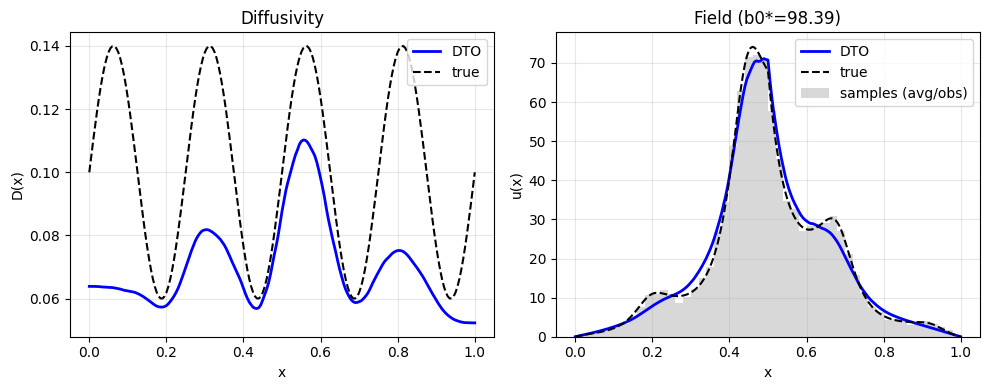

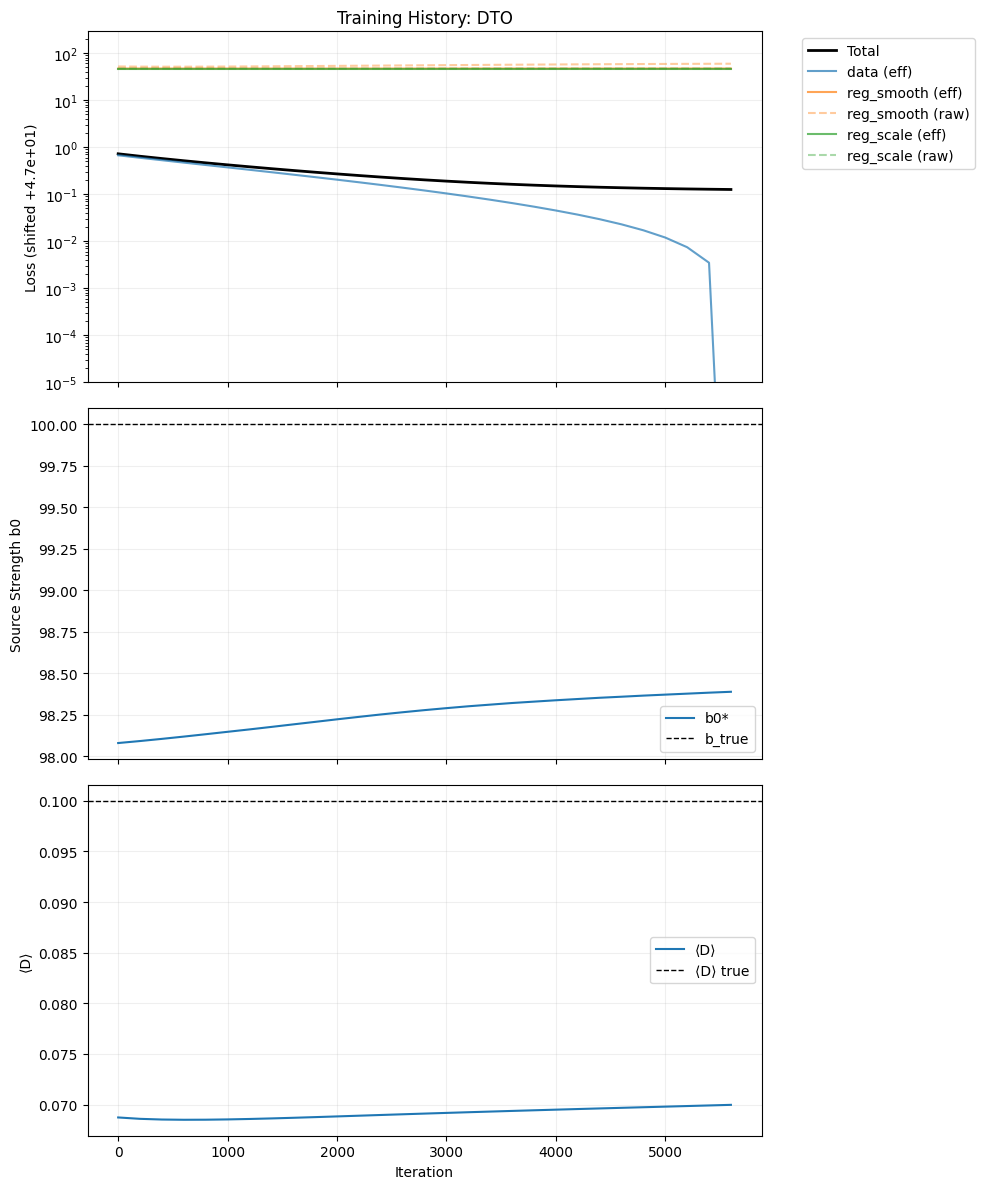

In [14]:

print("\n--- DTO (particles) ---")
dto_solution_ppp = solve(
    problem_ppp,
    method="dto",  # discretize-then-optimize solver
    **{**SHARED_CONFIG, **DTO_PARTICLE_CONFIG},
)


dto_metrics_ppp = dto_solution_ppp.metrics(problem_ppp)
print(f"DTO: particle-mode D(x) rel error = {dto_metrics_ppp['d_rel_error']:.2%}")
dto_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "DTO",
    dto_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=dto_solution_ppp.weights,
)


### Cell 8: Particle observations (PINN)



--- PINN (particles) ---
[Solve] Method: PINN | α: 0.0 | Mode: particles
[PINN] Initialized ⟨D⟩_base: 6.873e-02
[PINN|pretrain] Iter 00000 | Ltot: 4.330e+01
  Lphys: 3.656e+00 | Lanchor: 6.741e+00
  Lres: 3.556e+00 | Ljump: 9.979e-01
  ⟨D⟩: 9.221e-01
[PINN|pretrain] Iter 00200 | Ltot: 7.853e-01
  Lphys: 6.908e-02 | Lanchor: 9.442e-02
  Lres: 7.563e-03 | Ljump: 6.152e-01
  ⟨D⟩: 9.139e-02
[PINN|pretrain] Iter 00400 | Ltot: 6.242e-01
  Lphys: 6.043e-02 | Lanchor: 1.982e-02
  Lres: 6.172e-03 | Ljump: 5.426e-01
  ⟨D⟩: 7.636e-02
[PINN|pretrain] Iter 00600 | Ltot: 4.438e-01
  Lphys: 4.097e-02 | Lanchor: 3.410e-02
  Lres: 3.986e-03 | Ljump: 3.698e-01
  ⟨D⟩: 8.004e-02
[PINN|pretrain] Iter 00800 | Ltot: 1.955e-01
  Lphys: 1.494e-02 | Lanchor: 4.613e-02
  Lres: 1.750e-03 | Ljump: 1.319e-01
  ⟨D⟩: 8.088e-02
[PINN|pretrain] Iter 01000 | Ltot: 7.442e-02
  Lphys: 4.411e-03 | Lanchor: 3.031e-02
  Lres: 1.380e-03 | Ljump: 3.031e-02
  ⟨D⟩: 7.698e-02
[PINN|finetune] Iter 00000 | Ltot: -4.607e+01
  Ldata

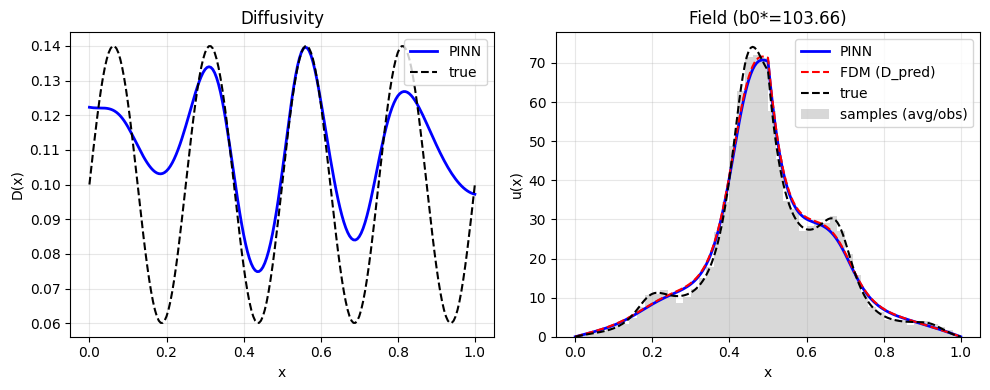

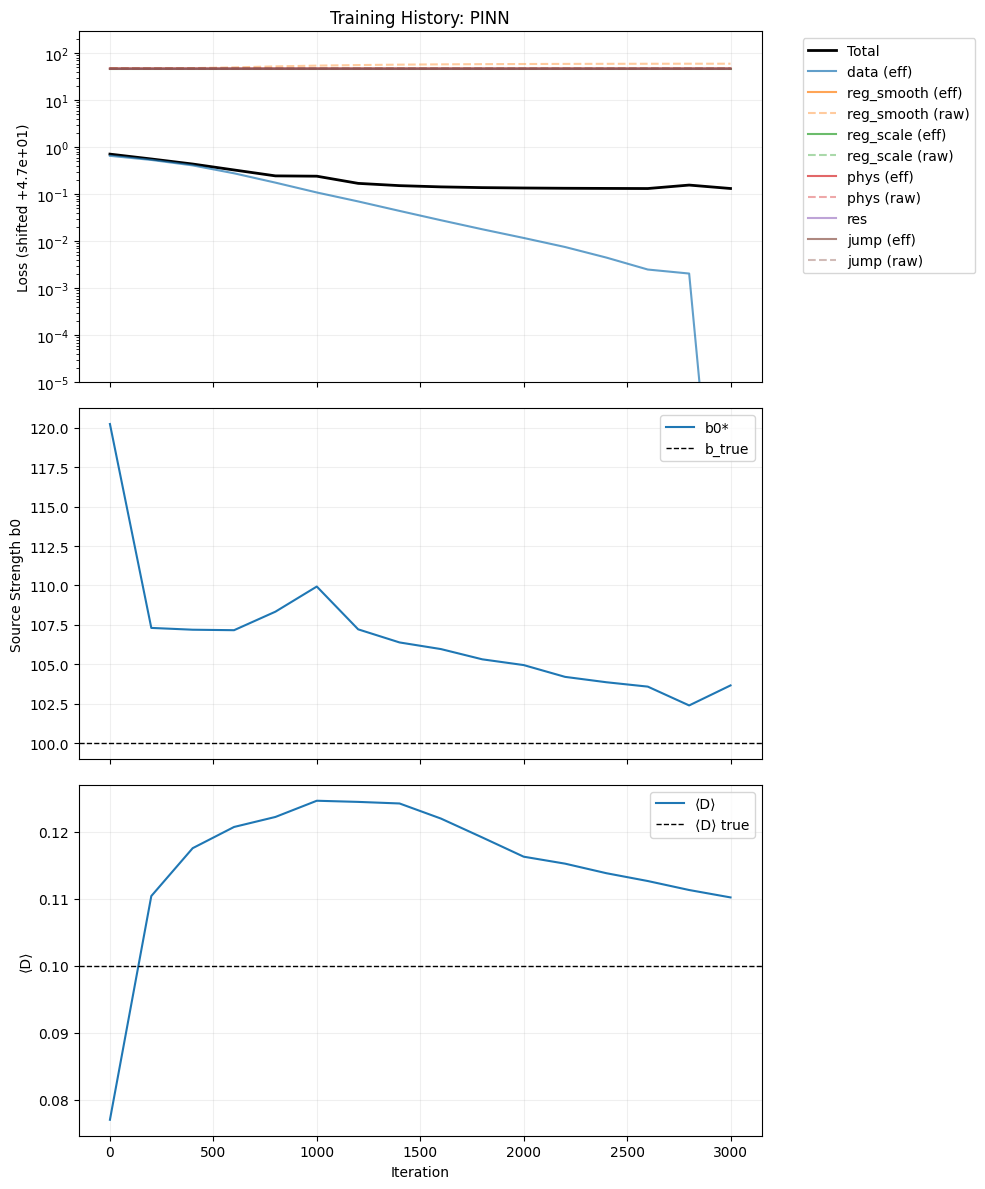

In [15]:
print("\n--- PINN (particles) ---")
pinn_solution_ppp = solve(
    problem_ppp,
    method="pinn",  # physics-informed neural network
    **{**SHARED_CONFIG, **PINN_PARTICLE_CONFIG},
)


pinn_metrics_ppp = pinn_solution_ppp.metrics(problem_ppp)
print(f"PINN: particle-mode D(x) rel error = {pinn_metrics_ppp['d_rel_error']:.2%}")
pinn_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "PINN",
    pinn_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=pinn_solution_ppp.weights,
)


### Cell 9: Particle observations (BiLO)



--- BiLO (particles) ---
[Solve] Method: BILO | α: 0.0 | Mode: particles
[BiLO] Initialized ⟨D⟩_base: 6.873e-02
[BiLO|pretrain] Iter 00000 | Ltot: 1.446e+01
  Lanchor: 8.332e+00 | Llower: 6.080e+00 | Lsup: 4.221e-02
  Lres: 4.965e+00 | Ljump: 1.083e+00 | Lrgrad: 3.277e+00 | Ljump_rgrad: 1.379e-03
  ⟨D⟩: 1.169e+00
[BiLO|pretrain] Iter 00200 | Ltot: 1.102e+00
  Lanchor: 2.643e-02 | Llower: 1.002e+00 | Lsup: 7.384e-02
  Lres: 1.691e-02 | Ljump: 9.846e-01 | Lrgrad: 1.205e-03 | Ljump_rgrad: 1.310e-04
  ⟨D⟩: 6.820e-02
[BiLO|pretrain] Iter 00400 | Ltot: 9.879e-01
  Lanchor: 1.892e-02 | Llower: 9.093e-01 | Lsup: 5.970e-02
  Lres: 4.529e-02 | Ljump: 8.637e-01 | Lrgrad: 1.867e-02 | Ljump_rgrad: 9.381e-03
  ⟨D⟩: 6.837e-02
[BiLO|pretrain] Iter 00600 | Ltot: 3.104e-01
  Lanchor: 1.369e-02 | Llower: 2.780e-01 | Lsup: 1.872e-02
  Lres: 7.487e-02 | Ljump: 1.908e-01 | Lrgrad: 7.862e-01 | Ljump_rgrad: 4.433e-01
  ⟨D⟩: 6.836e-02
[BiLO|pretrain] Iter 00800 | Ltot: 5.426e-02
  Lanchor: 9.307e-03 | Llower:

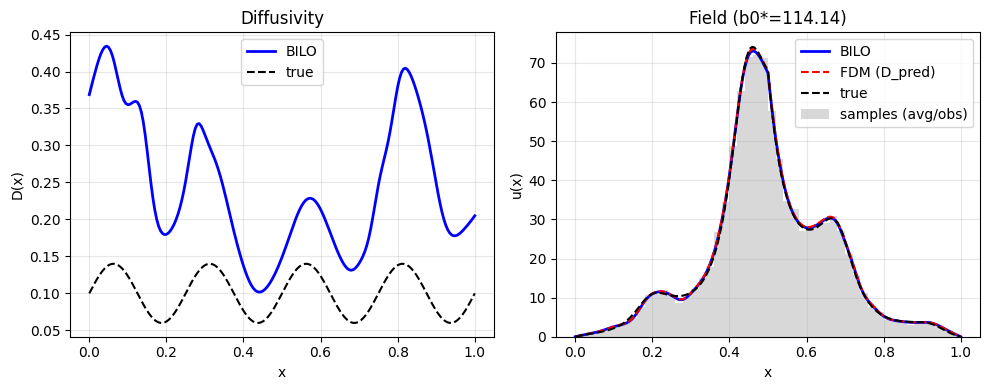

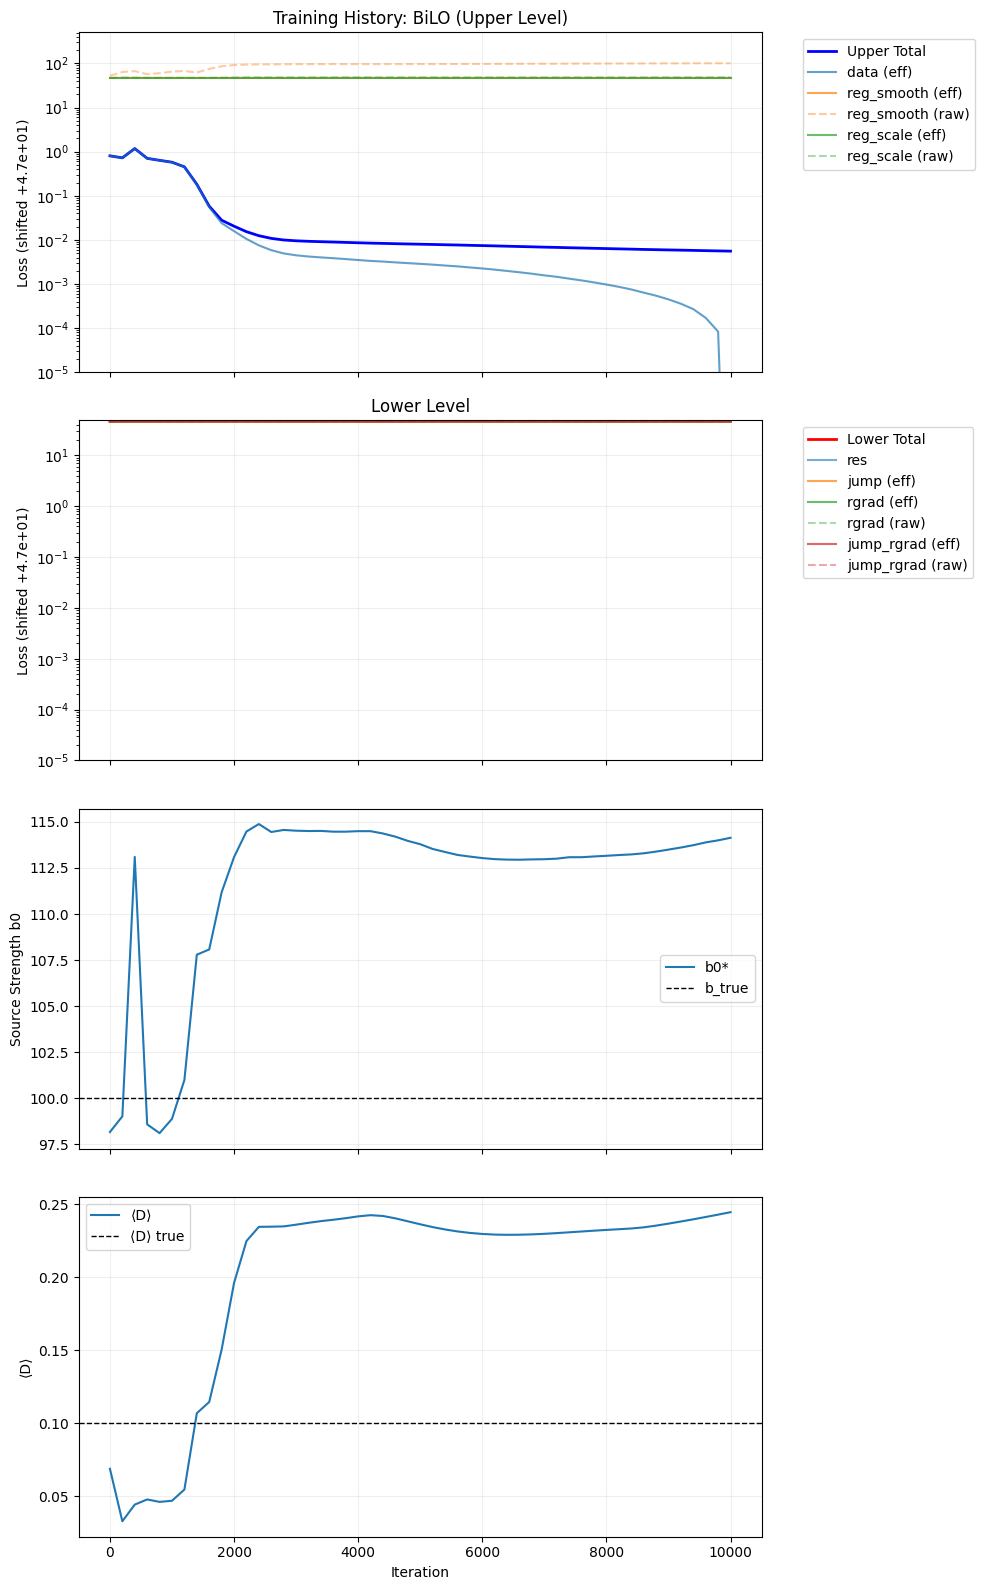

In [16]:
print("\n--- BiLO (particles) ---")
bilo_solution_ppp = solve(
    problem_ppp,
    method="bilo",  # bilevel local operator
    **{**SHARED_CONFIG, **BILO_PARTICLE_CONFIG},
)
bilo_metrics_ppp = bilo_solution_ppp.metrics(problem_ppp)
print(f"BiLO: particle-mode D(x) rel error = {bilo_metrics_ppp['d_rel_error']:.2%}")
bilo_solution_ppp.plot(problem_ppp)
diagnostics.plot_training_history(
    "BiLO",
    bilo_solution_ppp.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true_ppp,
    weights=bilo_solution_ppp.weights,
)
